Experiment No. 1 Title: Introduction to Keras

Aim: To implement a simple neural network using Keras for digit classification.

Software Required: Python, TensorFlow, Keras, NumPy, Matplotlib, Scikit-learn

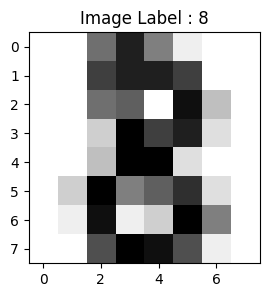

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5066 - loss: 1.7836 - val_accuracy: 0.8194 - val_loss: 1.0562
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8353 - loss: 0.7706 - val_accuracy: 0.8958 - val_loss: 0.4871
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9180 - loss: 0.3603 - val_accuracy: 0.9306 - val_loss: 0.3054
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9544 - loss: 0.2067 - val_accuracy: 0.9375 - val_loss: 0.2278
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9722 - loss: 0.1356 - val_accuracy: 0.9375 - val_loss: 0.1877
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9853 - loss: 0.0957 - val_accuracy: 0.9375 - val_loss: 0.1668
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9899 - loss: 0.0716 - val_accuracy: 0.9375 - val_loss: 0.1597
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9946 - loss: 0.0545 - val_accuracy: 0.9375 - v

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Load dataset
digits = load_digits()

# Display sample image with label 8
sample_index = np.where(digits.target == 8)[0][0]  # Find first image with label 8

plt.figure(figsize=(3,3))
plt.imshow(
    digits.images[sample_index],
    cmap=plt.cm.gray_r,
    interpolation='nearest'
)

plt.title("Image Label : %d" % digits.target[sample_index])
plt.show()

# Prepare data
data = np.asarray(digits.data, dtype='float32')
target = np.asarray(digits.target, dtype='int32')

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    data,
    target,
    test_size=0.2,
    random_state=42
)

# Normalize data
scaler = preprocessing.StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One Hot Encoding
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# Build Model
model = Sequential([
    Input(shape=(64,)),
    Dense(100, activation='relu'),
    Dense(50, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train,
    Y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.1
)

# Evaluate model
loss, accuracy = model.evaluate(X_test, Y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

Conclusion: Successfully implemented a neural network using Keras and achieved good accuracy on digit classification dataset.